# Micrograd Foundation: Derivatives and Autograd Engines

## This notebook establishes the mathematical and engineering foundation for building a scalar-valued autograd engine, similar to Andrej Karpathy's `micrograd`. We focus on understanding derivatives through numerical approximation before moving to computational graphs.


## 1. Mathematical Definition of a Derivative

- The derivative of a function $f(x)$ represents the instantaneous rate of change of the function with respect to $x$. It is formally defined as:

  
    f'(x) = lim(h→0) (f(x+h) - f(x)) / h

- In deep learning, these derivatives (gradients) tell us how to adjust our weights to minimize the loss function.




## 2. Setup and Environment

In [1]:
# !pip3 install numpy pandas
import math
import numpy as np
import matplotlib.pyplot as plt

# Configuration for professional visualization
plt.style.use('ggplot')
%matplotlib inline

## 3. Defining the Target Function
- We define a quadratic function $f(x) = 3x^2 - 4x + 5$. This function will serve as our test case for gradient calculation.

### 3. 1 Implementation of the Objective Function
def f(x: float) -> float:

    """
    Computes the value of the quadratic function 3x^2 - 4x + 5.
    
    Args:
        x (float): The input scalar value.
        
    Returns:
        float: The output of the quadratic function.
    """
    return 3*x**2 - 4*x + 5

### 3.2 Sample evaluation
print(f"f(3.0) = {f(3.0)}")

In [2]:
def f(x: float)-> float :
  return 3*x**2 - 4*x +5 
print(f"f(3.0) = {f(3.0)}")

f(3.0) = 20.0


## 4. Visual Analysis of the Function Space

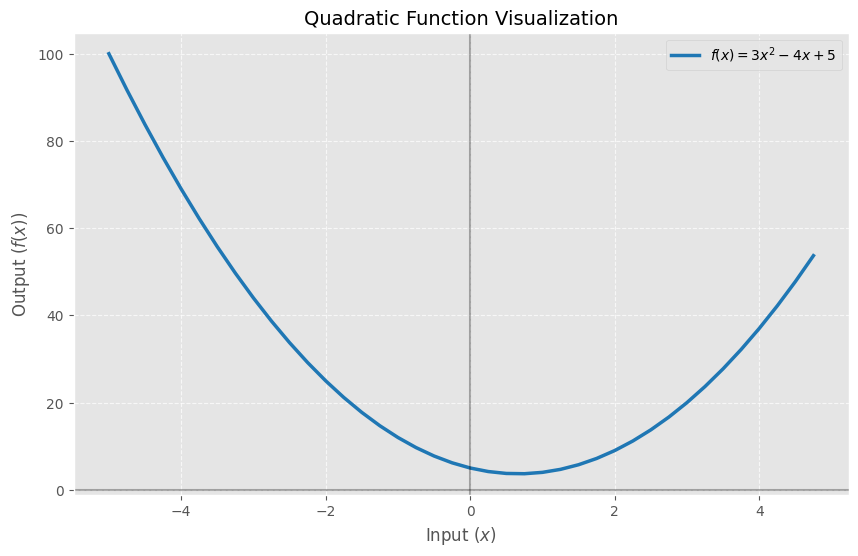

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.figure(figsize=(10, 6))
plt.plot(xs, ys, label=r"$f(x) = 3x^2 - 4x + 5$", color='#1f77b4', linewidth=2.5)
plt.title("Quadratic Function Visualization", fontsize=14)
plt.xlabel("Input ($x$)", fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5 Gradient Approximation:Derivatives of a single Variables
### 5.1 Analytical Soution
#### Derivative of the Function:
- To find the derivative of the quadratic function $f(x) = 3x^2 - 4x + 5$, we apply the Power Rule:
      - For any term $ax^n$, the derivative is $n \cdot ax^{n-1}$.

#### Step-by-Step Calculation:
- **Function:** $f(x) = 3x^2 - 4x + 5$
- **Applying the Power Rule:** $f'(x) = (2 \cdot 3x^{2-1}) - (1 \cdot 4x^{1-1}) + 0$
- **Result:**$$f'(x) = 6x - 4$$


### 5.2 Numerical Gradient Approximation

In [4]:
def get_numerical_gradient(func, x: float, h: float = 0.0001) -> float:
    """
    Estimates the derivative of a function at point x.
    
    Args:
        func: The callable function to differentiate.
        x: The point of evaluation.
        h: The infinitesimal step size.
        
    Returns:
        float: The approximated slope.
    """
    return (func(x + h) - func(x)) / h

# Configuration
step_size = 0.0001
target_x = 3.0
estimated_slope = get_numerical_gradient(f, target_x, step_size)

# Analytical Verification
# f(x)  = 3x^2 - 4x + 5
# f'(x) = 6x - 4
# f'(3) = 18 - 4 = 14
analytical_slope = 6 * target_x - 4

print(f"Numerical Approximation: {estimated_slope:.6f}")
print(f"Analytical Solution:    {analytical_slope:.6f}")

# Unit Test for Convergence
assert math.isclose(estimated_slope, analytical_slope, rel_tol=1e-3), \
    "Approximation error too high. Check h value."


Numerical Approximation: 14.000300
Analytical Solution:    14.000000


## Derivatives of Multiple Variables

### 6. Gradient Approximation: Derivatives of Multiple Variables

#### 6.1 Analytical Solution

To find the derivative of the function $f(a, b, c) = a \cdot b + c$, we calculate **partial derivatives**. This means we differentiate with respect to one variable while treating all others as constants 

**Core Rule (Power Rule):**
For any term $ax^n$, the derivative is $n \cdot ax^{n-1}$ .

##### Step-by-Step Calculation:

1. **Partial Derivative with respect to $a$ ($\frac{\partial f}{\partial a}$):**
   - **Logic:** Treat $b$ and $c$ as constants. The term $a \cdot b$ is linear with respect to $a$ (like $x \cdot 3$) ].
   - **Calculation:** The derivative of $a^1 \cdot b$ is $1 \cdot a^0 \cdot b = b$. The derivative of constant $c$ is $0$ .
   - **Result:** $\frac{\partial f}{\partial a} = b$ 

2. **Partial Derivative with respect to $b$ ($\frac{\partial f}{\partial b}$):**
   - **Logic:** Treat $a$ and $c$ as constants. The term $a \cdot b$ is linear with respect to $b$ .
   - **Calculation:** The derivative of $a \cdot b^1$ is $a \cdot 1 \cdot b^0 = a$. The derivative of constant $c$ is $0$ .
   - **Result:** $\frac{\partial f}{\partial b} = a$ 

3. **Partial Derivative with respect to $c$ ($\frac{\partial f}{\partial c}$):**
   - **Logic:** Treat $a$ and $b$ as constants. The entire term $a \cdot b$ is now a constant product .
   - **Calculation:** The derivative of the constant $a \cdot b$ is $0$. The derivative of $c^1$ is $1$ .
   - **Result:** $\frac{\partial f}{\partial c} = 1$ 

---

#### 6.2 Numerical Gradient Approximation

Numerical approximation estimates the derivative by looking at the "Rise over Run" for a very small step $h$.

**Formula:**
$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$ 

##### Example Walkthrough:
Suppose we have the values $a = 2, b = 3, c = 10$, and we choose a small step $h = 0.001$ 

**1. Original Output:**
$f(2, 3, 10) = (2 \cdot 3) + 10 = 16$ 

**2. Nudging $a$ to find $\frac{\partial f}{\partial a}$:**
- New $a = 2.001$ [cite: 1].
- New output: $f(2.001, 3, 10) = (2.001 \cdot 3) + 10 = 16.003$ 
- Approximation: $\frac{16.003 - 16}{0.001} = \mathbf{3}$ 
- *Note: This matches our analytical result where $\frac{\partial f}{\partial a} = b = 3$.* 

**3. Sensitivity Interpretation:**
- If we increase $a$, the output increases 
- If we increase $b$ (given $a$ is positive), the output increases 
- If we increase $c$, the output increases by the same amount 

In [5]:
import math

def f(a, b, c):
    """
    Function representing f(a, b, c) = a * b + c
    """
    return a * b + c

def get_multivariable_numerical_gradient(func, args, target_idx, h: float = 0.0001) -> float:
    """
    Estimates the partial derivative of a function with respect to one variable.
    
    Args:
        func: The multivariable function to differentiate.
        args: A tuple of the input values (e.g., (a, b, c)).
        target_idx: The index of the variable to 'nudge' (0 for a, 1 for b, 2 for c).
        h: The infinitesimal step size.
        
    Returns:
        float: The approximated partial derivative (gradient).
    """
    # 1. Calculate the original output
    f_original = func(*args)
    
    # 2. Nudge only the target variable by h
    nudged_args = list(args)
    nudged_args[target_idx] += h
    
    # 3. Calculate the new output
    f_nudged = func(*nudged_args)
    
    # 4. Return the slope: (Change in Output) / (Change in Input)
    return (f_nudged - f_original) / h

# --- Configuration ---
step_size = 0.001
inputs = (2.0, 3.0, 10.0)  # Represents a=2, b=3, c=10

# Calculate numerical gradients for each variable
grad_a = get_multivariable_numerical_gradient(f, inputs, 0, step_size)
grad_b = get_multivariable_numerical_gradient(f, inputs, 1, step_size)
grad_c = get_multivariable_numerical_gradient(f, inputs, 2, step_size)

# --- Analytical Verification ---
# For f(a, b, c) = a * b + c:
# df/da = b (Slope is 3.0)
# df/db = a (Slope is 2.0)
# df/dc = 1 (Slope is 1.0)
analytical_grad_a = inputs[1]
analytical_grad_b = inputs[0]
analytical_grad_c = 1.0

print(f"Partial wrt a -> Numerical: {grad_a:.6f}, Analytical: {analytical_grad_a:.6f}")
print(f"Partial wrt b -> Numerical: {grad_b:.6f}, Analytical: {analytical_grad_b:.6f}")
print(f"Partial wrt c -> Numerical: {grad_c:.6f}, Analytical: {analytical_grad_c:.6f}")

# Unit Test for Convergence
assert math.isclose(grad_a, analytical_grad_a, abs_tol=1e-3)
assert math.isclose(grad_b, analytical_grad_b, abs_tol=1e-3)
assert math.isclose(grad_c, analytical_grad_c, abs_tol=1e-3)

Partial wrt a -> Numerical: 3.000000, Analytical: 3.000000
Partial wrt b -> Numerical: 2.000000, Analytical: 2.000000
Partial wrt c -> Numerical: 1.000000, Analytical: 1.000000


## Micrograd: The Core Value Object
- Micrograd is an automatic differentiation engine that works on scalar values. While modern frameworks like PyTorch use N-dimensional tensors for efficiency, micrograd uses scalars to keep the underlying mathematics of backpropagation and the chain rule transparent.
### 1. The Anatomy of the `Value` Object
- The `Value` object is a wrapper around a single scalar number. It tracks the data, the gradient (derivative), and the operation that produced it to enable the recursive application of the chain rule.
### Core Attributes:
**data:** The actual numerical value (e.g., 2.0).

**grad:** The derivative of the final output (Loss) with respect to this value. Initialized to 0.0.

**_prev:** A set of the parent Value objects that participated in the operation.

**_op:** A string representing the operation (e.g., '+', '*').

**_backward:** A function that propagates the gradient from the current node back to its parents.

In [6]:
## skeleton of a very simple Value object
class Value:
    def __init__(self,data):
        self.data = data
    def __repr__(self):
        return f"Value(data={self.data})"

print(Value(2.0), Value(-3.0))

Value(data=2.0) Value(data=-3.0)


In [7]:
## simple operation using Value object
class Value:
    def __init__(self,data):
        self.data = data
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        return Value(self.data + other.data)

    def __mul__(self,other):
        return Value(self.data * other.data)

In [8]:
a,b,c = Value(2.0), Value(-3.0), Value(2.0)
print(a+b) #print(a.__add__(b))
print(a*b+c) # print(a.__mul__(b).__add__(c))



Value(data=-1.0)
Value(data=-4.0)


## Expression Graph
- we need to keep track what `Value`'s produces other `Value`s

In [9]:
## Expression Graph: Track parent Value objects that participated in the operation
class Value:
    def __init__(self,data, _children=()):
        self.data = data
        self._prev = set(_children)
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        return Value(self.data + other.data, (self, other))

    def __mul__(self,other):
        return Value(self.data * other.data, (self, other))

In [10]:
a,b,c = Value(2.0), Value(-3.0), Value(2.0)
d = a*b+c
print(d) # print(a.__mul__(b).__add__(c))
print(d._prev) #  # print(a*b, c)

Value(data=-4.0)
{Value(data=-6.0), Value(data=2.0)}


- Now we know the children of the value but we also want to keep track which operation created this. 

In [11]:
## Expression Graph: Track the operation
class Value:
    def __init__(self,data, _children=(), _op=''):
        self.data = data
        self._op = _op
        self._prev = set(_children)
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self,other):
        return Value(self.data * other.data, (self, other), '*')

In [12]:
d = a*b+c
print(d)
print(d._op) #  # print(a*b, c)

Value(data=-4.0)
+


In [13]:
!brew install graphviz
!pip3 install graphviz
import sys
!{sys.executable} -m pip install graphviz
from graphviz import Digraph

To reinstall 14.1.5, run:
  brew reinstall graphviz

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)


In [24]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f }" % (n.label,n.data), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

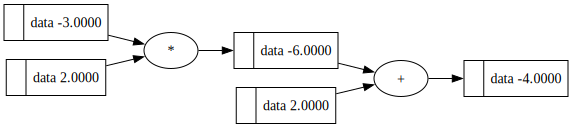

In [25]:
a = Value(2.0)
b = Value(-3.0)
c = Value(2.0)

d = a * b + c
draw_dot(d)

- Now Let's create labels for each of value:

In [26]:
## Expression Graph: Track the operation
class Value:
    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self._op = _op
        self.label= label
        self._prev = set(_children)
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self,other):
        return Value(self.data * other.data, (self, other), '*')

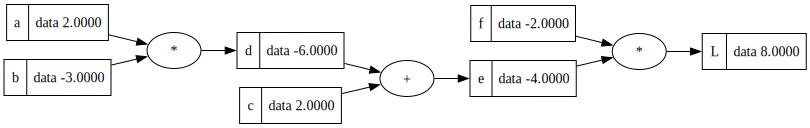

In [28]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(2.0,label='c')

d = a * b
d.label = 'd'
e = d+c 
e.label = 'e'
f = Value(-2.0,label='f')
L = e*f
L.label = 'L'
draw_dot(L)

In [29]:
## Expression Graph: Track The derivative of the final output (L) with respect to this value
class Value:
    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self._op = _op
        self.label= label
        self.grad = 0
        self._prev = set(_children)
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self,other):
        return Value(self.data * other.data, (self, other), '*')

In [30]:
def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label,n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

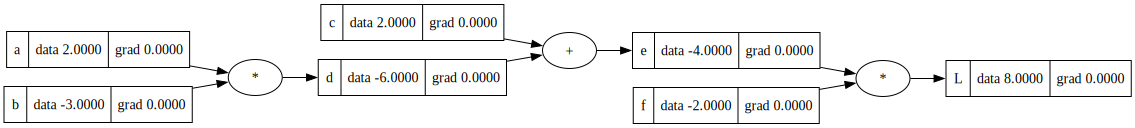

In [32]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(2.0,label='c')

d = a * b
d.label = 'd'
e = d+c 
e.label = 'e'
f = Value(-2.0,label='f')
L = e*f
L.label = 'L'
draw_dot(L)

### backpropagation example #1: simple expression